In [1]:
## 셀 1: 데이터 불러오기

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import folium

grid_master = gpd.read_file('grid_master_final.shp')
print(f"grid_master 격자 수: {len(grid_master)}")

road_gdf = gpd.read_file('03._상세도로망_lev6.geojson')
print(f"도로망 링크 수: {len(road_gdf)}")
print(road_gdf.columns.tolist())
print(road_gdf.crs)
print("grid_master CRS:", grid_master.crs)

grid_master 격자 수: 11388
도로망 링크 수: 3462
['link_id', 'up_f_node', 'up_t_node', 'dw_f_node', 'dw_t_node', 'max_speed', 'road_name', 'road_no', 'road_rank', 'link_type', 'pavement', 'road_type', 'facil_name', 'tg_name', 'up_lanes', 'dw_lanes', 'lanes', 'oneway', 'length', 'up_its_id', 'dw_its_id', 'sido_id', 'sigungu_id', 'emd_id', 'up_v_link', 'dw_v_link', 'm_date', 'rc_id', 'rc_name', 'rc_hist', 'rc_date', 'rc_length', 'old_link_i', 'geometry']
EPSG:4326
grid_master CRS: EPSG:4326


In [2]:
## 셀 2: 유동인구 통합변수 생성 (total_flow_pop)

pop_cols = [
    'm_10g_pop', 'm_20g_pop', 'm_30g_pop', 'm_40g_pop', 'm_50g_pop', 'm_60g_pop',
    'w_10g_pop', 'w_20g_pop', 'w_30g_pop', 'w_40g_pop', 'w_50g_pop', 'w_60g_pop'
]

grid_master['total_flow_pop'] = grid_master[pop_cols].sum(axis=1)
print(f"'total_flow_pop' 생성 완료, 최댓값: {grid_master['total_flow_pop'].max():.1f}명")

'total_flow_pop' 생성 완료, 최댓값: 13777.0명


In [4]:
## 셀 3: 사분면 판별 함수 + 목적지 설정

def get_quadrant(lon, lat, c_lon, c_lat):
    if lon >= c_lon and lat >= c_lat: return '1사분면(북동)'
    elif lon < c_lon and lat >= c_lat: return '2사분면(북서)'
    elif lon < c_lon and lat < c_lat: return '3사분면(남서)'
    else: return '4사분면(남동)'

destinations_v2 = {
    '야탑': (127.12873, 37.41131),
    '서현': (127.12397, 37.38474),
    '미금': (127.10891, 37.35016),
    '판교역': (127.10979, 37.39614),
}

In [5]:
## 셀 4: 좌표계 변환

grid_master['centroid_4326'] = grid_master.to_crs(epsg=4326).geometry.centroid
grid_master['lon'] = grid_master['centroid_4326'].x
grid_master['lat'] = grid_master['centroid_4326'].y

grid_master_m = grid_master.to_crs(epsg=5186)
grid_master_m['centroid_5186'] = grid_master_m.geometry.centroid

/tmp/ipykernel_9/3201882332.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid_master['centroid_4326'] = grid_master.to_crs(epsg=4326).geometry.centroid


In [6]:
## 셀 5: 목적지별 사분면 기준 동선후보 추출

routes_expanded = []

for name, (dest_lon, dest_lat) in destinations_v2.items():
    dp = Point(dest_lon, dest_lat)
    dp_m = gpd.GeoSeries([dp], crs='EPSG:4326').to_crs(epsg=5186).iloc[0]

    dist_km = grid_master_m['centroid_5186'].distance(dp_m) / 1000

    in_range_mask = (dist_km >= 0.8) & (dist_km <= 1.5)
    in_range_df = grid_master[in_range_mask].copy()
    in_range_df['dist_km'] = dist_km[in_range_mask]

    in_range_df['quadrant'] = in_range_df.apply(
        lambda row: get_quadrant(row['lon'], row['lat'], dest_lon, dest_lat), axis=1
    )

    for idx, row in in_range_df.iterrows():
        routes_expanded.append({
            '목적지': name,
            '출발지_grid_id': row['grid_id'],
            '거리_km': round(row['dist_km'], 3),
            '총_유동인구': round(row['total_flow_pop'], 2),
            '사분면': row['quadrant']
        })

routes_df = pd.DataFrame(routes_expanded)

routes_quadrant_top = (
    routes_df.sort_values(by=['목적지', '사분면', '총_유동인구'], ascending=[True, True, False])
    .groupby(['목적지', '사분면'])
    .head(1)
    .reset_index(drop=True)
)

print(f"=== 사분면 제약조건 적용 완료: 총 {len(routes_quadrant_top)}개 동선 확보 ===")
print(routes_quadrant_top[['목적지', '사분면', '출발지_grid_id', '거리_km', '총_유동인구']])

=== 사분면 제약조건 적용 완료: 총 16개 동선 확보 ===
    목적지       사분면  출발지_grid_id  거리_km   총_유동인구
0    미금  1사분면(북동)        50062  1.282  3810.66
1    미금  2사분면(북서)        48376  0.950  1304.90
2    미금  3사분면(남서)        53103  1.186  4167.21
3    미금  4사분면(남동)        53105  1.185  3240.54
4    서현  1사분면(북동)        31295  1.280  5557.96
5    서현  2사분면(북서)        33034  1.379  5506.34
6    서현  3사분면(남서)        40242  1.179  9079.99
7    서현  4사분면(남동)        40759  1.125  1256.77
8    야탑  1사분면(북동)        23441  0.855   572.73
9    야탑  2사분면(북서)        23297  0.856   447.40
10   야탑  3사분면(남서)        26514  0.855  1392.80
11   야탑  4사분면(남동)        23619  0.826   427.34
12  판교역  1사분면(북동)        26512  1.488  1285.38
13  판교역  2사분면(북서)        28620  1.357  3179.57
14  판교역  3사분면(남서)        36362  1.190   864.03
15  판교역  4사분면(남동)        33449  1.001  3946.02


In [7]:
## 셀 6: 지도 시각화 확인

colors = {'야탑':'red', '서현':'blue', '미금':'green', '판교역':'purple'}
center_lat = sum([lat for lon, lat in destinations_v2.values()]) / 4
center_lon = sum([lon for lon, lat in destinations_v2.values()]) / 4
m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

for name, (lon, lat) in destinations_v2.items():
    folium.Marker(
        location=[lat, lon],
        popup=f"<b>{name} (목적지)</b>",
        icon=folium.Icon(color=colors[name], icon='star')
    ).add_to(m)

for _, row in routes_quadrant_top.iterrows():
    dest_name = row['목적지']
    origin_id = row['출발지_grid_id']
    dest_lon, dest_lat = destinations_v2[dest_name]

    origin_row = grid_master[grid_master['grid_id'] == origin_id].iloc[0]
    origin_pt = origin_row.geometry.centroid

    folium.Marker(
        location=[origin_pt.y, origin_pt.x],
        popup=folium.Popup(
            f"<b>{dest_name} 출발지 ({row['사분면']})</b><br>"
            f"grid_id: {origin_id}<br>"
            f"총 유동인구: {row['총_유동인구']:,.0f}명<br>"
            f"거리: {row['거리_km']}km",
            max_width=250
        ),
        icon=folium.Icon(color=colors[dest_name], icon='user', prefix='fa')
    ).add_to(m)

    folium.PolyLine(
        locations=[[origin_pt.y, origin_pt.x], [dest_lat, dest_lon]],
        color=colors[dest_name], weight=2, dash_array='5, 5'
    ).add_to(m)

m

In [15]:
## 셀 7: OSM 인도 데이터 불러오기 + 판교분당 클립 + 인도류 필터링

osm_roads = gpd.read_file('gis_osm_roads_free_1.shp')
print(f"OSM roads 전체 링크 수: {len(osm_roads)}")

bbox = (127.05, 37.33, 127.16, 37.43)
osm_clip = osm_roads.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
print(f"판교분당 클립 후: {len(osm_clip)}")

footway_types = ['footway', 'path', 'pedestrian', 'steps']
sidewalk = osm_clip[osm_clip['fclass'].isin(footway_types)].copy()
print(f"인도류(footway/path/pedestrian/steps): {len(sidewalk)}")
print(sidewalk['fclass'].value_counts())

OSM roads 전체 링크 수: 1785187
판교분당 클립 후: 11625
인도류(footway/path/pedestrian/steps): 3130
fclass
footway       2433
path           384
steps          237
pedestrian      76
Name: count, dtype: int64


In [32]:
## 셀 8 수정: 03번 도로망 그래프 구축 (length 단위 km->m 보정)

import networkx as nx

G = nx.Graph()
for idx, row in road_gdf.iterrows():
    G.add_edge(
        row['up_f_node'], row['up_t_node'],
        weight=row['length'] * 1000,  # km -> m 단위 보정
        link_id=row['link_id'], source='03번'
    )

print(f"03번 기준 노드 수: {G.number_of_nodes()}")
print(f"03번 기준 엣지 수: {G.number_of_edges()}")

weights_check = [d['weight'] for u,v,d in G.edges(data=True)]
import numpy as np
print(f"weight 중앙값(수정 후): {np.median(weights_check):.1f}m (정상이면 수십~수백m)")

03번 기준 노드 수: 2740
03번 기준 엣지 수: 3462
weight 중앙값(수정 후): 63.0m (정상이면 수십~수백m)


In [33]:
## 셀 9: OSM 인도 링크를 그래프에 추가 (좌표 기반 신규 노드 생성)

sidewalk_5186 = sidewalk.to_crs(epsg=5186)

for idx, row in sidewalk_5186.iterrows():
    coords = list(row.geometry.coords)
    if len(coords) < 2:
        continue
    start_node = f"osm_{idx}_start"
    end_node = f"osm_{idx}_end"
    length = row.geometry.length  # 미터 단위 (5186 투영좌표계)

    G.add_edge(
        start_node, end_node,
        weight=length, link_id=f"osm_{row['osm_id']}",
        fclass=row['fclass'], source='OSM_인도'
    )

print(f"OSM 인도 추가 후 전체 노드 수: {G.number_of_nodes()}")
print(f"OSM 인도 추가 후 전체 엣지 수: {G.number_of_edges()}")

OSM 인도 추가 후 전체 노드 수: 9000
OSM 인도 추가 후 전체 엣지 수: 6592


In [45]:
## 셀 10 재실행: 반경 100m로 확대, cKDTree로 속도도 개선

from scipy.spatial import cKDTree
import numpy as np

node03_ids_arr = list(node03_coords.keys())
node03_pts_arr = np.array([[p.x, p.y] for p in node03_coords.values()])
tree = cKDTree(node03_pts_arr)

osm_ids_arr = list(osm_node_coords.keys())
osm_pts_arr = np.array([[p.x, p.y] for p in osm_node_coords.values()])

SNAP_THRESHOLD = 100.0
dists, idxs = tree.query(osm_pts_arr)

snap_count = 0
for i, (osm_id, dist, idx) in enumerate(zip(osm_ids_arr, dists, idxs)):
    if dist <= SNAP_THRESHOLD:
        nearest_03_id = node03_ids_arr[idx]
        G.add_edge(osm_id, nearest_03_id, weight=dist, source='snap_connection')
        snap_count += 1

print(f"반경 {SNAP_THRESHOLD}m 이내 매칭: {snap_count} / {len(osm_node_coords)}")
print(f"연결 후 전체 노드 수: {G.number_of_nodes()}")
print(f"연결 후 전체 엣지 수: {G.number_of_edges()}")

components = list(nx.connected_components(G))
print(f"\n연결된 덩어리 개수: {len(components)}")
print(f"가장 큰 덩어리의 노드 수: {len(max(components, key=len))}")

반경 100.0m 이내 매칭: 4219 / 6260
연결 후 전체 노드 수: 9000
연결 후 전체 엣지 수: 10811

연결된 덩어리 개수: 877
가장 큰 덩어리의 노드 수: 7243


In [46]:
## 셀 11: 가장 큰 연결 컴포넌트만 추출

largest_cc = max(components, key=len)
G_main = G.subgraph(largest_cc).copy()

print(f"정리 후 노드 수: {G_main.number_of_nodes()}")
print(f"정리 후 엣지 수: {G_main.number_of_edges()}")

# 03번 원래 노드가 이 안에 몇 개나 살아있는지 확인 (핵심 - 격자 매칭에 필요)
node03_in_main = sum(1 for n in node03_coords.keys() if n in G_main.nodes)
print(f"\n03번 원본 노드 중 큰 덩어리에 포함된 것: {node03_in_main} / {len(node03_coords)}")

정리 후 노드 수: 7243
정리 후 엣지 수: 9930

03번 원본 노드 중 큰 덩어리에 포함된 것: 2729 / 2740


In [47]:
## 셀 12: 최종 그래프 저장

import networkx as nx

nx.write_graphml(G_main, 'grid_road_network_with_sidewalk.graphml')
print("저장 완료: grid_road_network_with_sidewalk.graphml")
print(f"노드 {G_main.number_of_nodes()}개, 엣지 {G_main.number_of_edges()}개")

저장 완료: grid_road_network_with_sidewalk.graphml
노드 7243개, 엣지 9930개


/tmp/ipykernel_9/3108696269.py:35: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/3108696269.py:35: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/3108696269.py:35: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/3108696269.py:35: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/3108696269.py:35: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/3108696269.py:35: UserWarning: Glyph 48337 (\N{HANGUL SYLLABLE BYEONG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/3108696269.py:35: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/3108696269.py:35: UserWarning: Glyph 45348 

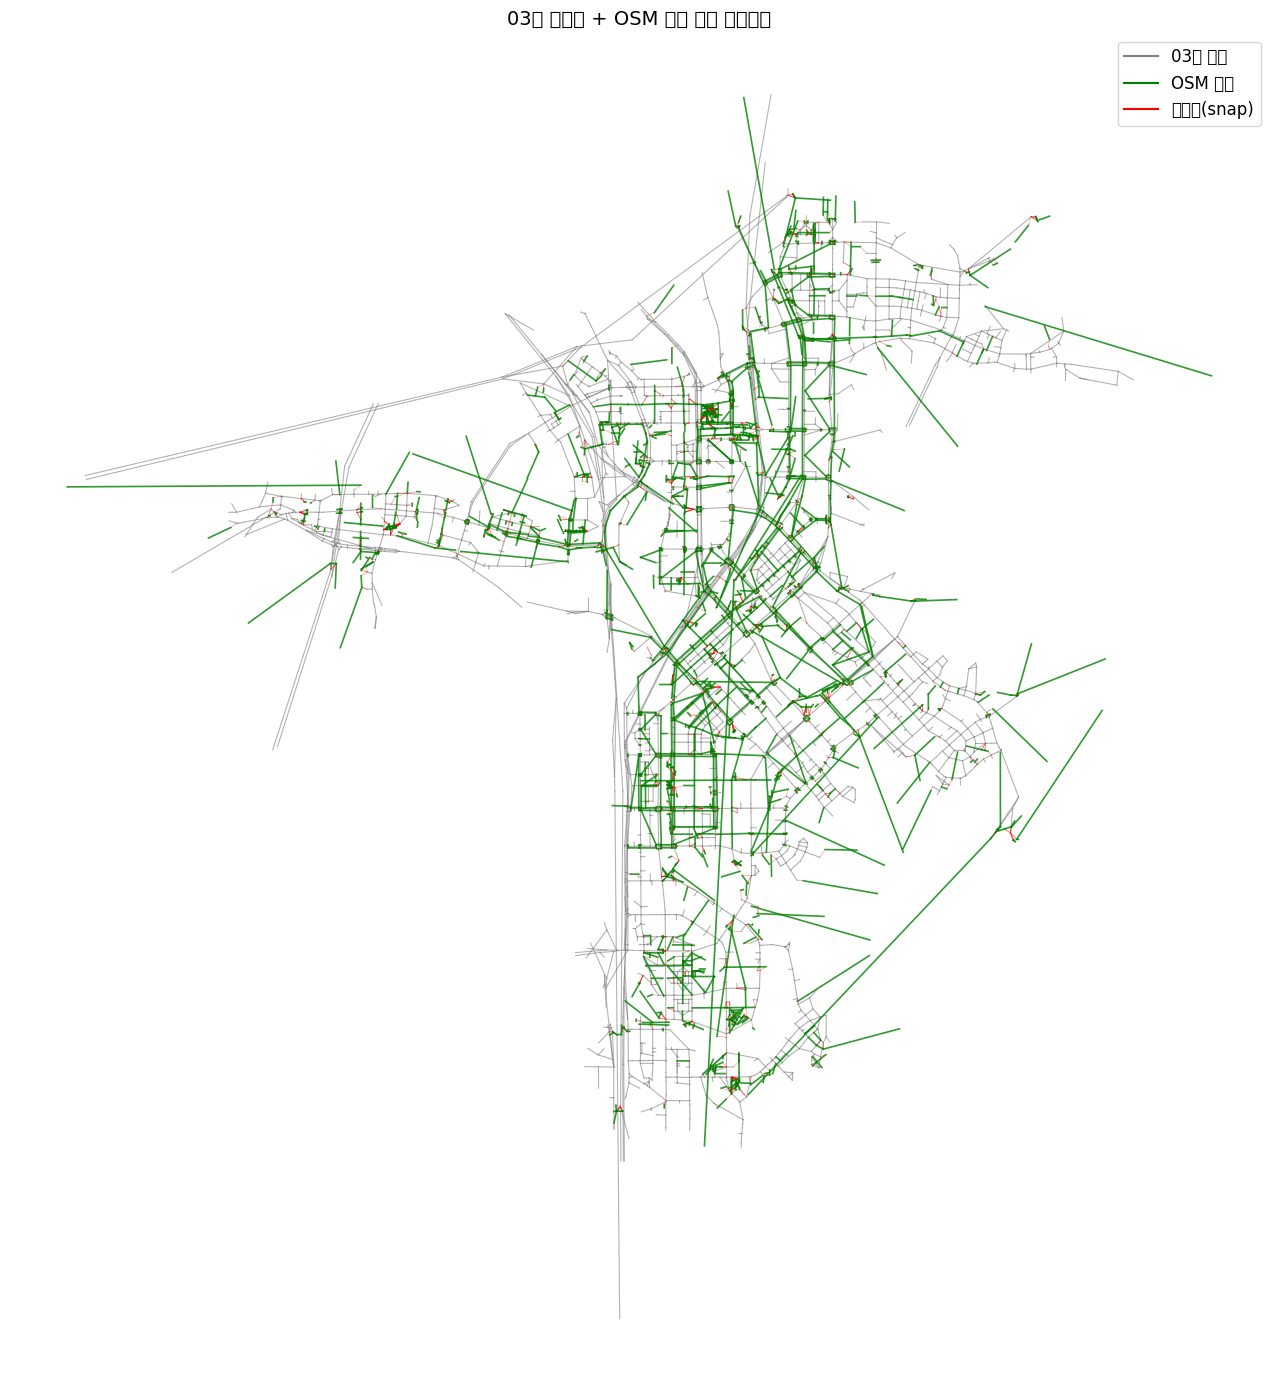

In [48]:
## 셀 13: 병합 네트워크 시각화 (03번 vs OSM 인도 vs 연결선 구분)

import matplotlib.pyplot as plt

# 노드 좌표 딕셔너리 준비 (03번 + OSM 인도)
all_node_coords = {**node03_coords, **osm_node_coords}

fig, ax = plt.subplots(figsize=(14, 14))

for u, v, data in G_main.edges(data=True):
    if u not in all_node_coords or v not in all_node_coords:
        continue
    p1 = all_node_coords[u]
    p2 = all_node_coords[v]

    source = data.get('source', '03번')
    if source == '03번':
        color, lw, alpha = 'gray', 0.8, 0.6
    elif source == 'OSM_인도':
        color, lw, alpha = 'green', 1.2, 0.8
    else:  # snap_connection
        color, lw, alpha = 'red', 0.5, 0.4

    ax.plot([p1.x, p2.x], [p1.y, p2.y], color=color, linewidth=lw, alpha=alpha)

# 범례용 더미 라인
ax.plot([], [], color='gray', label='03번 차도')
ax.plot([], [], color='green', label='OSM 인도')
ax.plot([], [], color='red', label='연결선(snap)')
ax.legend(loc='upper right', fontsize=12)

ax.set_title('03번 도로망 + OSM 인도 병합 네트워크', fontsize=14)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

In [49]:
## 셀 14: 격자 중심점 -> 도로망 노드 매칭 (cKDTree)

import numpy as np
from scipy.spatial import cKDTree
from shapely.geometry import Point

# G_main에 있는 노드들의 좌표 딕셔너리 재구성 (03번 + OSM 인도 통합)
all_node_coords = {**node03_coords, **osm_node_coords}
graph_node_coords = {n: all_node_coords[n] for n in G_main.nodes if n in all_node_coords}

node_ids = list(graph_node_coords.keys())
node_pts = np.array([[p.x, p.y] for p in graph_node_coords.values()])
tree = cKDTree(node_pts)

def find_nearest_graph_node(grid_id, grid_gdf_5186):
    """grid_id -> G_main 내 가장 가까운 노드 반환 (EPSG:5186 기준)"""
    row = grid_gdf_5186[grid_gdf_5186['grid_id'] == grid_id].iloc[0]
    centroid = row.geometry.centroid
    dist, idx = tree.query([centroid.x, centroid.y])
    return node_ids[idx], dist

# grid_master를 5186으로 변환 (거리계산 통일)
grid_master_5186 = grid_master.to_crs(epsg=5186)

print("격자 -> 도로망 노드 매칭 함수 준비 완료")
print(f"매칭 대상 그래프 노드 수: {len(node_ids)}")

격자 -> 도로망 노드 매칭 함수 준비 완료
매칭 대상 그래프 노드 수: 7243


In [50]:
## 셀 15: 목적지 4개 + 출발지(사분면) 노드 매칭

# 목적지 대표 grid_id (08번에서 썼던 것과 동일)
dest_grid_ids = {
    '야탑': 23412,
    '서현': 38207,
    '미금': 50277,
    '판교역': 30721,
}

dest_nodes = {}
for name, gid in dest_grid_ids.items():
    node, dist = find_nearest_graph_node(gid, grid_master_5186)
    dest_nodes[name] = node
    print(f"목적지 {name}(grid_id {gid}) -> 노드 {node} (거리 {dist:.1f}m)")

print()

origin_nodes = {}
for _, row in routes_quadrant_top.iterrows():
    gid = row['출발지_grid_id']
    if gid not in origin_nodes:
        node, dist = find_nearest_graph_node(gid, grid_master_5186)
        origin_nodes[gid] = node
        print(f"출발지 grid_id {gid} -> 노드 {node} (거리 {dist:.1f}m)")

목적지 야탑(grid_id 23412) -> 노드 353073 (거리 20.3m)
목적지 서현(grid_id 38207) -> 노드 353941 (거리 21.0m)
목적지 미금(grid_id 50277) -> 노드 osm_1755073_start (거리 15.2m)
목적지 판교역(grid_id 30721) -> 노드 337723 (거리 7.3m)

출발지 grid_id 50062 -> 노드 900043 (거리 89.2m)
출발지 grid_id 48376 -> 노드 336741 (거리 66.9m)
출발지 grid_id 53103 -> 노드 336877 (거리 29.4m)
출발지 grid_id 53105 -> 노드 336877 (거리 36.0m)
출발지 grid_id 31295 -> 노드 352982 (거리 66.1m)
출발지 grid_id 33034 -> 노드 osm_1281673_start (거리 65.0m)
출발지 grid_id 40242 -> 노드 osm_1133930_start (거리 30.5m)
출발지 grid_id 40759 -> 노드 osm_1283040_start (거리 13.2m)
출발지 grid_id 23441 -> 노드 osm_166078_end (거리 14.8m)
출발지 grid_id 23297 -> 노드 337678 (거리 33.8m)
출발지 grid_id 26514 -> 노드 osm_1281198_start (거리 45.3m)
출발지 grid_id 23619 -> 노드 352614 (거리 45.5m)
출발지 grid_id 26512 -> 노드 336462 (거리 53.0m)
출발지 grid_id 28620 -> 노드 337148 (거리 13.9m)
출발지 grid_id 36362 -> 노드 osm_1431284_start (거리 30.2m)
출발지 grid_id 33449 -> 노드 osm_1199737_end (거리 72.5m)


In [51]:
## 셀 16: Dijkstra 최단경로 계산

import networkx as nx
import pandas as pd

routes_result_v2 = []

for _, row in routes_quadrant_top.iterrows():
    dest_name = row['목적지']
    origin_id = row['출발지_grid_id']
    quadrant = row['사분면']

    origin_node = origin_nodes[origin_id]
    dest_node = dest_nodes[dest_name]

    try:
        path = nx.shortest_path(G_main, source=origin_node, target=dest_node, weight='weight')
        path_length = nx.shortest_path_length(G_main, source=origin_node, target=dest_node, weight='weight')

        routes_result_v2.append({
            '목적지': dest_name,
            '사분면': quadrant,
            '출발지_grid_id': origin_id,
            '출발지_노드': origin_node,
            '목적지_노드': dest_node,
            '경로_길이_m': round(path_length, 1),
            '경로_노드수': len(path),
            '경로': path
        })
        print(f"✅ {dest_name}({quadrant}) ← {origin_id}: {path_length:.1f}m, 노드 {len(path)}개")
    except nx.NetworkXNoPath:
        print(f"❌ {dest_name}({quadrant}) ← {origin_id}: 경로 없음 (연결 안 됨)")
        routes_result_v2.append({
            '목적지': dest_name, '사분면': quadrant, '출발지_grid_id': origin_id, '경로_길이_m': None
        })

routes_result_v2_df = pd.DataFrame(routes_result_v2)
print(f"\n총 {len(routes_result_v2_df)}개 중 성공: {routes_result_v2_df['경로_길이_m'].notna().sum()}개")

✅ 미금(1사분면(북동)) ← 50062: 1686.1m, 노드 21개
✅ 미금(2사분면(북서)) ← 48376: 1242.1m, 노드 13개
✅ 미금(3사분면(남서)) ← 53103: 1189.1m, 노드 17개
✅ 미금(4사분면(남동)) ← 53105: 1189.1m, 노드 17개
✅ 서현(1사분면(북동)) ← 31295: 1506.8m, 노드 20개
✅ 서현(2사분면(북서)) ← 33034: 1938.2m, 노드 25개
✅ 서현(3사분면(남서)) ← 40242: 1379.7m, 노드 16개
✅ 서현(4사분면(남동)) ← 40759: 1786.0m, 노드 26개
✅ 야탑(1사분면(북동)) ← 23441: 1206.0m, 노드 13개
✅ 야탑(2사분면(북서)) ← 23297: 1125.0m, 노드 14개
✅ 야탑(3사분면(남서)) ← 26514: 1121.5m, 노드 15개
✅ 야탑(4사분면(남동)) ← 23619: 1113.0m, 노드 12개
✅ 판교역(1사분면(북동)) ← 26512: 1834.9m, 노드 31개
✅ 판교역(2사분면(북서)) ← 28620: 1968.0m, 노드 26개
✅ 판교역(3사분면(남서)) ← 36362: 1305.4m, 노드 21개
✅ 판교역(4사분면(남동)) ← 33449: 1451.9m, 노드 23개

총 16개 중 성공: 16개


In [52]:
## 확인: 그래프 엣지 가중치(weight) 값 분포 체크

import numpy as np

weights = [d['weight'] for u, v, d in G_main.edges(data=True)]
weights = np.array(weights)

print("전체 엣지 weight 분포:")
print("min:", weights.min(), "max:", weights.max())
print("percentile 10/25/50/75/90:", np.percentile(weights, [10,25,50,75,90]))
print()

# source별로 나눠서 확인
for src in ['03번', 'OSM_인도', 'snap_connection']:
    w = [d['weight'] for u, v, d in G_main.edges(data=True) if d.get('source')==src]
    if w:
        w = np.array(w)
        print(f"[{src}] 개수: {len(w)}, min: {w.min():.4f}, max: {w.max():.2f}, median: {np.median(w):.4f}")

전체 엣지 weight 분포:
min: 0.5742047420422858 max: 7132.724628840975
percentile 10/25/50/75/90: [ 13.          21.43427001  41.91188753  84.         167.        ]

[03번] 개수: 3454, min: 4.0000, max: 5524.00, median: 63.0000
[OSM_인도] 개수: 2257, min: 0.5742, max: 7132.72, median: 39.4802
[snap_connection] 개수: 4219, min: 0.9025, max: 99.97, median: 28.9680


In [53]:
## 셀 17: 직선거리 대비 우회율 계산 + 저장

from shapely.geometry import Point
import geopandas as gpd

for idx, row in routes_result_v2_df.iterrows():
    if pd.isna(row['경로_길이_m']):
        continue

    origin_id = row['출발지_grid_id']
    dest_name = row['목적지']

    origin_row = grid_master_5186[grid_master_5186['grid_id'] == origin_id].iloc[0]
    origin_pt = origin_row.geometry.centroid

    dest_lon, dest_lat = destinations_v2[dest_name]
    dest_pt = gpd.GeoSeries([Point(dest_lon, dest_lat)], crs='EPSG:4326').to_crs(epsg=5186).iloc[0]

    straight_dist = origin_pt.distance(dest_pt)
    routes_result_v2_df.loc[idx, '직선거리_m'] = round(straight_dist, 1)
    routes_result_v2_df.loc[idx, '우회율_%'] = round((row['경로_길이_m'] / straight_dist - 1) * 100, 1)

print(routes_result_v2_df[['목적지', '사분면', '출발지_grid_id', '직선거리_m', '경로_길이_m', '우회율_%']])

# 저장 (경로 컬럼은 리스트라 CSV엔 문자열로)
save_df = routes_result_v2_df.copy()
save_df['경로'] = save_df['경로'].apply(lambda x: '|'.join(map(str, x)) if isinstance(x, list) else x)
save_df.to_csv('shortest_paths_v2_final.csv', index=False, encoding='utf-8-sig')
print("\n저장 완료: shortest_paths_v2_final.csv")

    목적지       사분면  출발지_grid_id  직선거리_m  경로_길이_m  우회율_%
0    미금  1사분면(북동)        50062  1282.3   1686.1   31.5
1    미금  2사분면(북서)        48376   949.7   1242.1   30.8
2    미금  3사분면(남서)        53103  1186.1   1189.1    0.2
3    미금  4사분면(남동)        53105  1185.4   1189.1    0.3
4    서현  1사분면(북동)        31295  1280.3   1506.8   17.7
5    서현  2사분면(북서)        33034  1379.4   1938.2   40.5
6    서현  3사분면(남서)        40242  1179.5   1379.7   17.0
7    서현  4사분면(남동)        40759  1125.4   1786.0   58.7
8    야탑  1사분면(북동)        23441   855.1   1206.0   41.0
9    야탑  2사분면(북서)        23297   856.3   1125.0   31.4
10   야탑  3사분면(남서)        26514   855.4   1121.5   31.1
11   야탑  4사분면(남동)        23619   826.2   1113.0   34.7
12  판교역  1사분면(북동)        26512  1488.5   1834.9   23.3
13  판교역  2사분면(북서)        28620  1357.1   1968.0   45.0
14  판교역  3사분면(남서)        36362  1190.0   1305.4    9.7
15  판교역  4사분면(남동)        33449  1000.8   1451.9   45.1

저장 완료: shortest_paths_v2_final.csv


In [54]:
## 셀 18: 16개 최단경로 지도 시각화

import folium

colors = {'야탑':'red', '서현':'blue', '미금':'green', '판교역':'purple'}

center_lat = sum([lat for lon, lat in destinations_v2.values()]) / 4
center_lon = sum([lon for lon, lat in destinations_v2.values()]) / 4
m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles='cartodbpositron')

# 목적지 마커
for name, (lon, lat) in destinations_v2.items():
    folium.Marker(
        location=[lat, lon],
        popup=f"<b>{name} (목적지)</b>",
        icon=folium.Icon(color=colors[name], icon='star')
    ).add_to(m)

# 노드 좌표는 EPSG:5186 기준이니 4326으로 변환해서 그려야 함
all_node_coords_4326 = {}
for n, pt in all_node_coords.items():
    gs = gpd.GeoSeries([pt], crs='EPSG:5186').to_crs(epsg=4326)
    all_node_coords_4326[n] = gs.iloc[0]

for _, row in routes_result_v2_df.iterrows():
    if pd.isna(row['경로_길이_m']):
        continue
    dest_name = row['목적지']
    path_nodes = row['경로']

    path_coords = [
        [all_node_coords_4326[n].y, all_node_coords_4326[n].x]
        for n in path_nodes if n in all_node_coords_4326
    ]

    folium.PolyLine(
        locations=path_coords,
        color=colors[dest_name],
        weight=3,
        opacity=0.8,
        popup=f"{dest_name} ({row['사분면']}) ← {row['출발지_grid_id']}<br>"
              f"경로:{row['경로_길이_m']}m / 우회율:{row['우회율_%']}%"
    ).add_to(m)

    # 출발지 마커
    origin_pt_4326 = all_node_coords_4326.get(origin_nodes[row['출발지_grid_id']])
    if origin_pt_4326 is not None:
        folium.CircleMarker(
            location=[origin_pt_4326.y, origin_pt_4326.x],
            radius=5,
            color=colors[dest_name],
            fill=True,
            popup=f"출발지 {row['출발지_grid_id']} ({row['사분면']})"
        ).add_to(m)

m

In [55]:
## 셀 19: 도로+인도 통합 geometry 준비 (버퍼 대상)

# 03번 도로 + OSM 인도를 하나의 GeoDataFrame으로 통합 (link_id 통일)
road_gdf_calc = road_gdf[['link_id', 'geometry']].copy()
road_gdf_calc['source'] = '03번'

sidewalk_calc = sidewalk[['osm_id', 'geometry']].copy()
sidewalk_calc['link_id'] = 'osm_' + sidewalk_calc['osm_id'].astype(str)
sidewalk_calc['source'] = 'OSM_인도'
sidewalk_calc = sidewalk_calc[['link_id', 'geometry', 'source']]

all_links_gdf = pd.concat([road_gdf_calc, sidewalk_calc], ignore_index=True)
print(f"통합 링크 수: {len(all_links_gdf)} (03번 {len(road_gdf_calc)} + OSM인도 {len(sidewalk_calc)})")

통합 링크 수: 6592 (03번 3462 + OSM인도 3130)


In [56]:
## 셀 20: 격자 HSI 결합 + 12m 버퍼 + 링크별 HSI 면적가중평균

hsi_col = 'HSI'

# grid_HSI_final_result_v3.csv 불러와서 grid_master에 HSI 결합
hsi_df = pd.read_csv('grid_HSI_final_result_v3.csv', usecols=['grid_id', 'HSI'])
grid_master_hsi = grid_master.merge(hsi_df, on='grid_id', how='left')
grid_master_hsi[hsi_col] = pd.to_numeric(grid_master_hsi[hsi_col], errors='coerce')

print(f"HSI 매칭된 격자 수: {grid_master_hsi[hsi_col].notna().sum()} / {len(grid_master_hsi)}")

# EPSG:5186 투영좌표계 변환
all_links_5186 = all_links_gdf.to_crs(epsg=5186)
grid_m = grid_master_hsi.to_crs(epsg=5186)

# 12m 버퍼 생성 (확정 기준)
buffer_radius_m = 12
link_buffer = all_links_5186.copy()
link_buffer['geometry'] = link_buffer.geometry.buffer(buffer_radius_m)

# 공간교차 + 면적가중평균
intersection = gpd.overlay(
    link_buffer,
    grid_m[['grid_id', hsi_col, 'geometry']],
    how='intersection'
)

intersection['inter_area'] = intersection.geometry.area
intersection['hsi_x_area'] = intersection[hsi_col] * intersection['inter_area']

link_hsi_summary = intersection.groupby('link_id').agg(
    total_hsi_x_area=('hsi_x_area', 'sum'),
    total_inter_area=('inter_area', 'sum')
).reset_index()

link_hsi_summary['link_hsi'] = link_hsi_summary['total_hsi_x_area'] / link_hsi_summary['total_inter_area']

print(f"HSI 계산된 링크 수: {len(link_hsi_summary)} / {len(all_links_gdf)}")
print(link_hsi_summary['link_hsi'].describe())

HSI 매칭된 격자 수: 11388 / 11388
HSI 계산된 링크 수: 5509 / 6592
count    5509.000000
mean        0.643726
std         0.178611
min         0.003460
25%         0.543081
50%         0.676283
75%         0.776554
max         0.990279
Name: link_hsi, dtype: float64


In [57]:
## 확인: 16개 동선 경로가 link_hsi 결측 링크를 지나는지 체크

missing_link_check = []
for _, row in routes_result_v2_df.iterrows():
    if pd.isna(row['경로_길이_m']):
        continue
    path_nodes = row['경로']
    link_ids_in_path = []
    for i in range(len(path_nodes) - 1):
        u, v = path_nodes[i], path_nodes[i+1]
        edge_data = G_main.get_edge_data(u, v)
        if edge_data and 'link_id' in edge_data:
            link_ids_in_path.append(edge_data['link_id'])

    matched = link_hsi_summary[link_hsi_summary['link_id'].isin(link_ids_in_path)]
    missing_count = len(link_ids_in_path) - len(matched)
    missing_link_check.append({
        '목적지': row['목적지'], '사분면': row['사분면'],
        '전체링크수': len(link_ids_in_path), 'HSI누락링크수': missing_count
    })

pd.DataFrame(missing_link_check)

In [58]:
## 셀 21: 경로별 평균 HSI 계산

def calculate_route_hsi(path_nodes, G_main, link_hsi_summary, all_links_gdf):
    if not path_nodes or len(path_nodes) < 2:
        return None

    link_ids = []
    link_lengths = []
    for i in range(len(path_nodes) - 1):
        u, v = path_nodes[i], path_nodes[i+1]
        edge_data = G_main.get_edge_data(u, v)
        if edge_data and 'link_id' in edge_data:
            link_ids.append(edge_data['link_id'])
            link_lengths.append(edge_data.get('weight', 0))

    if not link_ids:
        return None

    matched = link_hsi_summary[link_hsi_summary['link_id'].isin(link_ids)]
    link_len_map = dict(zip(link_ids, link_lengths))
    matched = matched.copy()
    matched['length'] = matched['link_id'].map(link_len_map)
    matched = matched.dropna(subset=['link_hsi', 'length'])

    if len(matched) == 0 or matched['length'].sum() == 0:
        return None

    avg_hsi = (matched['link_hsi'] * matched['length']).sum() / matched['length'].sum()
    return round(avg_hsi, 3)

routes_result_v2_df['경로_평균_HSI'] = routes_result_v2_df.apply(
    lambda r: calculate_route_hsi(r['경로'], G_main, link_hsi_summary, all_links_gdf) if pd.notna(r['경로_길이_m']) else None,
    axis=1
)

print(routes_result_v2_df[['목적지', '사분면', '출발지_grid_id', '경로_길이_m', '경로_평균_HSI']])

    목적지       사분면  출발지_grid_id  경로_길이_m  경로_평균_HSI
0    미금  1사분면(북동)        50062   1686.1      0.658
1    미금  2사분면(북서)        48376   1242.1      0.703
2    미금  3사분면(남서)        53103   1189.1      0.618
3    미금  4사분면(남동)        53105   1189.1      0.618
4    서현  1사분면(북동)        31295   1506.8      0.650
5    서현  2사분면(북서)        33034   1938.2      0.738
6    서현  3사분면(남서)        40242   1379.7      0.861
7    서현  4사분면(남동)        40759   1786.0      0.692
8    야탑  1사분면(북동)        23441   1206.0      0.710
9    야탑  2사분면(북서)        23297   1125.0      0.697
10   야탑  3사분면(남서)        26514   1121.5      0.694
11   야탑  4사분면(남동)        23619   1113.0      0.707
12  판교역  1사분면(북동)        26512   1834.9      0.684
13  판교역  2사분면(북서)        28620   1968.0      0.709
14  판교역  3사분면(남서)        36362   1305.4      0.681
15  판교역  4사분면(남동)        33449   1451.9      0.720


In [59]:
## 셀 22: 링크 HSI를 그래프 엣지 속성으로 추가

link_hsi_map = dict(zip(link_hsi_summary['link_id'], link_hsi_summary['link_hsi']))

# 결측 링크는 전체 평균으로 대체 (그래프 계산 끊기지 않게)
mean_hsi = link_hsi_summary['link_hsi'].mean()

missing_count = 0
for u, v, data in G_main.edges(data=True):
    lid = data.get('link_id')
    hsi_val = link_hsi_map.get(lid, mean_hsi)
    if lid not in link_hsi_map:
        missing_count += 1
    G_main[u][v]['link_hsi'] = hsi_val

print(f"HSI 결측으로 평균 대체된 엣지 수: {missing_count} / {G_main.number_of_edges()}")

HSI 결측으로 평균 대체된 엣지 수: 4703 / 9930


In [60]:
## 셀 23: α 스캔 (0.2~2.0) - 회피경로 계산

import numpy as np

alpha_values = np.arange(0.2, 2.01, 0.2)  # 0.2, 0.4, ..., 2.0 (10개)

def build_cost_graph(G, alpha):
    """비용함수 실거리*(1+alpha*링크HSI) 적용한 그래프 복사본 생성"""
    G_cost = G.copy()
    for u, v, data in G_cost.edges(data=True):
        real_dist = data['weight']
        link_hsi = data.get('link_hsi', mean_hsi)
        data['cost'] = real_dist * (1 + alpha * link_hsi)
    return G_cost

alpha_results = []

for alpha in alpha_values:
    G_cost = build_cost_graph(G_main, alpha)

    for _, row in routes_result_v2_df.iterrows():
        if pd.isna(row['경로_길이_m']):
            continue

        origin_node = row['출발지_노드']
        dest_node = row['목적지_노드']

        try:
            avoid_path = nx.shortest_path(G_cost, source=origin_node, target=dest_node, weight='cost')
            avoid_dist = sum(G_main[avoid_path[i]][avoid_path[i+1]]['weight'] for i in range(len(avoid_path)-1))
            avoid_hsi = calculate_route_hsi(avoid_path, G_main, link_hsi_summary, all_links_gdf)

            alpha_results.append({
                'alpha': alpha,
                '목적지': row['목적지'],
                '사분면': row['사분면'],
                '출발지_grid_id': row['출발지_grid_id'],
                '최단경로_거리_m': row['경로_길이_m'],
                '최단경로_HSI': row['경로_평균_HSI'],
                '회피경로_거리_m': round(avoid_dist, 1),
                '회피경로_HSI': avoid_hsi,
                '회피경로': avoid_path
            })
        except nx.NetworkXNoPath:
            alpha_results.append({
                'alpha': alpha, '목적지': row['목적지'], '사분면': row['사분면'],
                '출발지_grid_id': row['출발지_grid_id'], '회피경로_거리_m': None
            })

alpha_results_df = pd.DataFrame(alpha_results)
print(f"총 {len(alpha_results_df)}개 결과 (16개 경로 × {len(alpha_values)}개 α값)")
print(alpha_results_df[['alpha', '목적지', '사분면', '최단경로_거리_m', '회피경로_거리_m', '최단경로_HSI', '회피경로_HSI']].head(20))

총 160개 결과 (16개 경로 × 10개 α값)
    alpha  목적지       사분면  최단경로_거리_m  회피경로_거리_m  최단경로_HSI  회피경로_HSI
0     0.2   미금  1사분면(북동)     1686.1     1686.1     0.658     0.658
1     0.2   미금  2사분면(북서)     1242.1     1252.1     0.703     0.657
2     0.2   미금  3사분면(남서)     1189.1     1189.1     0.618     0.618
3     0.2   미금  4사분면(남동)     1189.1     1189.1     0.618     0.618
4     0.2   서현  1사분면(북동)     1506.8     1506.8     0.650     0.650
5     0.2   서현  2사분면(북서)     1938.2     1938.2     0.738     0.738
6     0.2   서현  3사분면(남서)     1379.7     1380.7     0.861     0.846
7     0.2   서현  4사분면(남동)     1786.0     1786.0     0.692     0.692
8     0.2   야탑  1사분면(북동)     1206.0     1206.0     0.710     0.710
9     0.2   야탑  2사분면(북서)     1125.0     1125.0     0.697     0.697
10    0.2   야탑  3사분면(남서)     1121.5     1134.4     0.694     0.579
11    0.2   야탑  4사분면(남동)     1113.0     1114.0     0.707     0.682
12    0.2  판교역  1사분면(북동)     1834.9     1834.9     0.684     0.675
13    0.2  판교역  2사분면(북서)     1968.

In [62]:
## 셀 22: 링크 HSI를 그래프 엣지 속성으로 추가 (스냅연결선은 인접링크 HSI 사용)

link_hsi_map = dict(zip(link_hsi_summary['link_id'], link_hsi_summary['link_hsi']))
mean_hsi = link_hsi_summary['link_hsi'].mean()

missing_count = 0
snap_filled = 0

for u, v, data in G_main.edges(data=True):
    source = data.get('source', '')
    lid = data.get('link_id')

    if source == 'snap_connection':
        neighbor_hsi = None
        for node in [u, v]:
            for neighbor in G_main.neighbors(node):
                if neighbor == u or neighbor == v:
                    continue
                edge = G_main.get_edge_data(node, neighbor)
                if edge and edge.get('source') != 'snap_connection' and edge.get('link_id') in link_hsi_map:
                    neighbor_hsi = link_hsi_map[edge['link_id']]
                    break
            if neighbor_hsi is not None:
                break
        hsi_val = neighbor_hsi if neighbor_hsi is not None else mean_hsi
        if neighbor_hsi is None:
            missing_count += 1
        else:
            snap_filled += 1
    else:
        hsi_val = link_hsi_map.get(lid, mean_hsi)
        if lid not in link_hsi_map:
            missing_count += 1

    G_main[u][v]['link_hsi'] = hsi_val

print(f"스냅 연결선 중 인접 링크 HSI로 채워진 것: {snap_filled}")
print(f"최종 결측(평균 대체)으로 남은 엣지 수: {missing_count} / {G_main.number_of_edges()}")

스냅 연결선 중 인접 링크 HSI로 채워진 것: 4131
최종 결측(평균 대체)으로 남은 엣지 수: 572 / 9930


In [64]:
## 셀 23: α 스캔 (0.2~2.0) - 회피경로 계산

import numpy as np

alpha_values = np.arange(0.2, 2.01, 0.2)

def build_cost_graph(G, alpha):
    G_cost = G.copy()
    for u, v, data in G_cost.edges(data=True):
        real_dist = data['weight']
        link_hsi = data.get('link_hsi', mean_hsi)
        data['cost'] = real_dist * (1 + alpha * link_hsi)
    return G_cost

alpha_results = []

for alpha in alpha_values:
    G_cost = build_cost_graph(G_main, alpha)

    for _, row in routes_result_v2_df.iterrows():
        if pd.isna(row['경로_길이_m']):
            continue

        origin_node = row['출발지_노드']
        dest_node = row['목적지_노드']

        try:
            avoid_path = nx.shortest_path(G_cost, source=origin_node, target=dest_node, weight='cost')
            avoid_dist = sum(G_main[avoid_path[i]][avoid_path[i+1]]['weight'] for i in range(len(avoid_path)-1))
            avoid_hsi = calculate_route_hsi(avoid_path, G_main, link_hsi_summary, all_links_gdf)

            alpha_results.append({
                'alpha': alpha,
                '목적지': row['목적지'],
                '사분면': row['사분면'],
                '출발지_grid_id': row['출발지_grid_id'],
                '최단경로_거리_m': row['경로_길이_m'],
                '최단경로_HSI': row['경로_평균_HSI'],
                '회피경로_거리_m': round(avoid_dist, 1),
                '회피경로_HSI': avoid_hsi,
                '회피경로': avoid_path
            })
        except nx.NetworkXNoPath:
            alpha_results.append({
                'alpha': alpha, '목적지': row['목적지'], '사분면': row['사분면'],
                '출발지_grid_id': row['출발지_grid_id'], '회피경로_거리_m': None
            })

alpha_results_df = pd.DataFrame(alpha_results)
print(f"총 {len(alpha_results_df)}개 결과")

# alpha=2.0에서 최단/회피 차이 확인
alpha_2 = alpha_results_df[alpha_results_df['alpha'] == 2.0].copy()
alpha_2['거리차이_m'] = alpha_2['회피경로_거리_m'] - alpha_2['최단경로_거리_m']
alpha_2['HSI차이'] = alpha_2['최단경로_HSI'] - alpha_2['회피경로_HSI']
print("\n=== alpha=2.0 (최대 회피 성향) 결과 ===")
print(alpha_2[['목적지','사분면','거리차이_m','HSI차이']])

총 160개 결과

=== alpha=2.0 (최대 회피 성향) 결과 ===
     목적지       사분면  거리차이_m  HSI차이
144   미금  1사분면(북동)     0.0  0.000
145   미금  2사분면(북서)    32.0  0.070
146   미금  3사분면(남서)     0.0  0.000
147   미금  4사분면(남동)     0.0  0.000
148   서현  1사분면(북동)    27.0  0.034
149   서현  2사분면(북서)    76.2  0.054
150   서현  3사분면(남서)     1.0  0.015
151   서현  4사분면(남동)    39.3  0.063
152   야탑  1사분면(북동)     0.0  0.000
153   야탑  2사분면(북서)     0.0  0.000
154   야탑  3사분면(남서)    12.9  0.115
155   야탑  4사분면(남동)     1.0  0.025
156  판교역  1사분면(북동)     0.0  0.009
157  판교역  2사분면(북서)    27.5  0.039
158  판교역  3사분면(남서)     1.9  0.020
159  판교역  4사분면(남동)    12.5  0.019


In [65]:
## 셀 25: α 확장 스캔 (2.0을 넘어서 5.0, 10.0까지)

alpha_values_ext = [2.0, 3.0, 5.0, 8.0, 10.0]

alpha_results_ext = []

for alpha in alpha_values_ext:
    G_cost = build_cost_graph(G_main, alpha)

    for _, row in routes_result_v2_df.iterrows():
        if pd.isna(row['경로_길이_m']):
            continue

        origin_node = row['출발지_노드']
        dest_node = row['목적지_노드']

        try:
            avoid_path = nx.shortest_path(G_cost, source=origin_node, target=dest_node, weight='cost')
            avoid_dist = sum(G_main[avoid_path[i]][avoid_path[i+1]]['weight'] for i in range(len(avoid_path)-1))
            avoid_hsi = calculate_route_hsi(avoid_path, G_main, link_hsi_summary, all_links_gdf)

            alpha_results_ext.append({
                'alpha': alpha,
                '목적지': row['목적지'],
                '사분면': row['사분면'],
                '최단경로_거리_m': row['경로_길이_m'],
                '최단경로_HSI': row['경로_평균_HSI'],
                '회피경로_거리_m': round(avoid_dist, 1),
                '회피경로_HSI': avoid_hsi,
            })
        except nx.NetworkXNoPath:
            pass

alpha_ext_df = pd.DataFrame(alpha_results_ext)
alpha_ext_df['거리차이_m'] = alpha_ext_df['회피경로_거리_m'] - alpha_ext_df['최단경로_거리_m']
alpha_ext_df['HSI차이'] = alpha_ext_df['최단경로_HSI'] - alpha_ext_df['회피경로_HSI']

# alpha별 평균 회피효과 요약
summary = alpha_ext_df.groupby('alpha')[['거리차이_m', 'HSI차이']].mean()
print("=== alpha별 평균 회피효과 ===")
print(summary)

print("\n=== alpha=10.0 상세 ===")
print(alpha_ext_df[alpha_ext_df['alpha']==10.0][['목적지','사분면','거리차이_m','HSI차이']])

=== alpha별 평균 회피효과 ===
         거리차이_m     HSI차이
alpha                    
2.0    14.45625  0.028937
3.0    33.53750  0.038937
5.0    33.53750  0.038937
8.0    59.27500  0.050312
10.0   64.98750  0.053250

=== alpha=10.0 상세 ===
    목적지       사분면  거리차이_m  HSI차이
64   미금  1사분면(북동)     0.0  0.000
65   미금  2사분면(북서)    32.0  0.070
66   미금  3사분면(남서)     0.0  0.000
67   미금  4사분면(남동)     0.0  0.000
68   서현  1사분면(북동)   118.4  0.081
69   서현  2사분면(북서)    76.2  0.054
70   서현  3사분면(남서)     1.0  0.015
71   서현  4사분면(남동)    39.3  0.063
72   야탑  1사분면(북동)     2.0  0.002
73   야탑  2사분면(북서)     0.0  0.000
74   야탑  3사분면(남서)    12.9  0.115
75   야탑  4사분면(남동)     3.0  0.027
76  판교역  1사분면(북동)   301.3  0.165
77  판교역  2사분면(북서)    27.5  0.039
78  판교역  3사분면(남서)     1.9  0.020
79  판교역  4사분면(남동)   424.3  0.201


In [66]:
## 셀 26: α 더 넓게 + 촘촘하게 스캔 (한계효용 확인)

alpha_values_wide = [0.2, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 15.0, 20.0, 30.0]

alpha_results_wide = []

for alpha in alpha_values_wide:
    G_cost = build_cost_graph(G_main, alpha)

    for _, row in routes_result_v2_df.iterrows():
        if pd.isna(row['경로_길이_m']):
            continue

        origin_node = row['출발지_노드']
        dest_node = row['목적지_노드']

        try:
            avoid_path = nx.shortest_path(G_cost, source=origin_node, target=dest_node, weight='cost')
            avoid_dist = sum(G_main[avoid_path[i]][avoid_path[i+1]]['weight'] for i in range(len(avoid_path)-1))
            avoid_hsi = calculate_route_hsi(avoid_path, G_main, link_hsi_summary, all_links_gdf)

            alpha_results_wide.append({
                'alpha': alpha,
                '목적지': row['목적지'],
                '사분면': row['사분면'],
                '최단경로_거리_m': row['경로_길이_m'],
                '최단경로_HSI': row['경로_평균_HSI'],
                '회피경로_거리_m': round(avoid_dist, 1),
                '회피경로_HSI': avoid_hsi,
            })
        except nx.NetworkXNoPath:
            pass

alpha_wide_df = pd.DataFrame(alpha_results_wide)
alpha_wide_df['거리차이_m'] = alpha_wide_df['회피경로_거리_m'] - alpha_wide_df['최단경로_거리_m']
alpha_wide_df['우회율_%'] = (alpha_wide_df['거리차이_m'] / alpha_wide_df['최단경로_거리_m'] * 100)
alpha_wide_df['HSI차이'] = alpha_wide_df['최단경로_HSI'] - alpha_wide_df['회피경로_HSI']
alpha_wide_df['저감률_%'] = (alpha_wide_df['HSI차이'] / alpha_wide_df['최단경로_HSI'] * 100)

summary_wide = alpha_wide_df.groupby('alpha')[['거리차이_m', '우회율_%', 'HSI차이', '저감률_%']].mean().round(3)
print("=== alpha별 평균 회피효과 (전 구간) ===")
print(summary_wide)

=== alpha별 평균 회피효과 (전 구간) ===
       거리차이_m  우회율_%  HSI차이  저감률_%
alpha                             
0.2     1.675  0.141  0.015  2.075
0.5     3.206  0.233  0.017  2.364
1.0     8.069  0.516  0.024  3.406
1.5    13.081  0.778  0.027  3.902
2.0    14.456  0.889  0.029  4.116
3.0    33.537  1.936  0.039  5.576
4.0    33.537  1.936  0.039  5.576
5.0    33.537  1.936  0.039  5.576
6.0    33.537  1.936  0.039  5.576
8.0    59.275  3.709  0.050  7.156
10.0   64.987  4.088  0.053  7.608
15.0   64.987  4.088  0.053  7.608
20.0   64.987  4.088  0.053  7.608
30.0   90.562  6.047  0.064  9.223


/tmp/ipykernel_9/793412702.py:20: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_9/793412702.py:20: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_9/793412702.py:20: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_9/793412702.py:20: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_9/793412702.py:20: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_9/793412702.py:20: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_9/793412702.py:20: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from current font.
  fig.tight_layout()
/tmp/ipykernel_9/793412702.py:20: UserWarning: Glyph 44048 (\N{HANGUL S

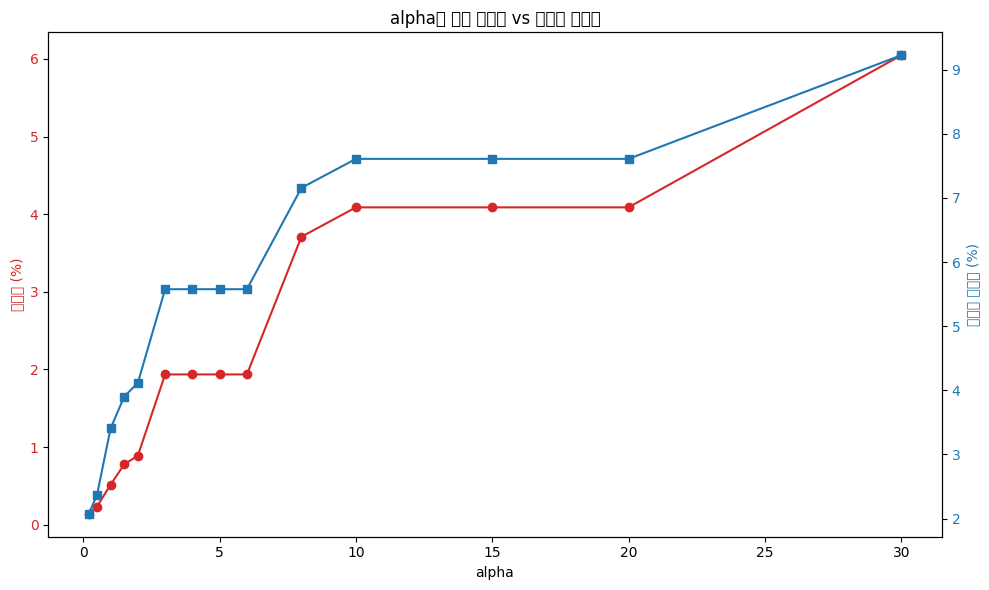

/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/app-root/lib/python3.8/sit

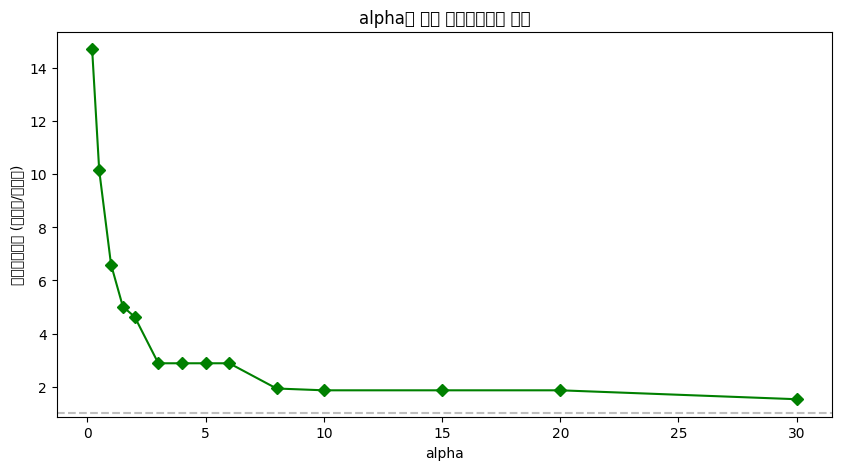

=== 회피효율지수 표 ===
alpha
0.2     14.72
0.5     10.15
1.0      6.60
1.5      5.02
2.0      4.63
3.0      2.88
4.0      2.88
5.0      2.88
6.0      2.88
8.0      1.93
10.0     1.86
15.0     1.86
20.0     1.86
30.0     1.53
dtype: float64


In [67]:
## 셀 27: α별 우회율·저감률 곡선 시각화

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:red'
ax1.set_xlabel('alpha')
ax1.set_ylabel('우회율 (%)', color=color1)
ax1.plot(summary_wide.index, summary_wide['우회율_%'], color=color1, marker='o', label='우회율')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('열노출 저감률 (%)', color=color2)
ax2.plot(summary_wide.index, summary_wide['저감률_%'], color=color2, marker='s', label='저감률')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('alpha에 따른 우회율 vs 열노출 저감률')
fig.tight_layout()
plt.show()

# 회피효율지수(저감률/우회율) 별도 그래프
plt.figure(figsize=(10, 5))
efficiency = summary_wide['저감률_%'] / summary_wide['우회율_%']
plt.plot(summary_wide.index, efficiency, color='green', marker='D')
plt.xlabel('alpha')
plt.ylabel('회피효율지수 (저감률/우회율)')
plt.title('alpha에 따른 회피효율지수 변화')
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
plt.show()

print("=== 회피효율지수 표 ===")
print(efficiency.round(2))

In [68]:
## 셀 28: 최종 결과 저장

# 1. 링크별 HSI 대표값 저장
link_hsi_summary.to_csv('link_hsi_summary.csv', index=False, encoding='utf-8-sig')

# 2. alpha별 전체 스캔 결과 저장 (경로 리스트는 문자열로 변환)
alpha_wide_df.to_csv('alpha_scan_results.csv', index=False, encoding='utf-8-sig')

# 3. alpha별 평균 요약(우회율/저감률/효율지수) 저장
summary_wide['효율지수'] = (summary_wide['저감률_%'] / summary_wide['우회율_%']).round(2)
summary_wide.to_csv('alpha_scan_summary.csv', encoding='utf-8-sig')

print("저장 완료:")
print("- link_hsi_summary.csv:", link_hsi_summary.shape)
print("- alpha_scan_results.csv:", alpha_wide_df.shape)
print("- alpha_scan_summary.csv:", summary_wide.shape)
print()
print(summary_wide)

저장 완료:
- link_hsi_summary.csv: (5509, 4)
- alpha_scan_results.csv: (224, 11)
- alpha_scan_summary.csv: (14, 5)

       거리차이_m  우회율_%  HSI차이  저감률_%   효율지수
alpha                                    
0.2     1.675  0.141  0.015  2.075  14.72
0.5     3.206  0.233  0.017  2.364  10.15
1.0     8.069  0.516  0.024  3.406   6.60
1.5    13.081  0.778  0.027  3.902   5.02
2.0    14.456  0.889  0.029  4.116   4.63
3.0    33.537  1.936  0.039  5.576   2.88
4.0    33.537  1.936  0.039  5.576   2.88
5.0    33.537  1.936  0.039  5.576   2.88
6.0    33.537  1.936  0.039  5.576   2.88
8.0    59.275  3.709  0.050  7.156   1.93
10.0   64.987  4.088  0.053  7.608   1.86
15.0   64.987  4.088  0.053  7.608   1.86
20.0   64.987  4.088  0.053  7.608   1.86
30.0   90.562  6.047  0.064  9.223   1.53


In [69]:
## 셀 29: 곤란구간 후보 도출 (조건A: HSI 상위등급 관통 / 조건B: 회피효율 낮음)

# 조건 A: 최단경로들이 지나가는 링크 중 HSI 상위 20% 이상인 것들 집계
hsi_threshold = link_hsi_summary['link_hsi'].quantile(0.8)
print(f"HSI 상위 20% 임계값: {hsi_threshold:.3f}")

link_pass_count = {}
for _, row in routes_result_v2_df.iterrows():
    if pd.isna(row['경로_길이_m']):
        continue
    path_nodes = row['경로']
    for i in range(len(path_nodes) - 1):
        u, v = path_nodes[i], path_nodes[i+1]
        edge_data = G_main.get_edge_data(u, v)
        lid = edge_data.get('link_id') if edge_data else None
        if lid:
            link_pass_count[lid] = link_pass_count.get(lid, 0) + 1

pass_df = pd.DataFrame(list(link_pass_count.items()), columns=['link_id', 'pass_count'])
pass_df = pass_df.merge(link_hsi_summary, on='link_id', how='left')

condition_A = pass_df[pass_df['link_hsi'] >= hsi_threshold].sort_values('pass_count', ascending=False)
print(f"\n조건A(HSI 상위20% & 최단경로가 지나감) 해당 링크 수: {len(condition_A)}")
print(condition_A.head(10))

# 조건 B: alpha=10에서도 거리차이가 거의 0인 O-D (회피 불가능한 동선)
alpha_10 = alpha_wide_df[alpha_wide_df['alpha'] == 10.0].copy()
condition_B = alpha_10[alpha_10['거리차이_m'] < 5]  # 5m 미만이면 사실상 회피 안 됨

print(f"\n조건B(alpha=10에서도 회피 불가능한 동선) 개수: {len(condition_B)}")
print(condition_B[['목적지', '사분면', '거리차이_m', '우회율_%']])

HSI 상위 20% 임계값: 0.799

조건A(HSI 상위20% & 최단경로가 지나감) 해당 링크 수: 76
       link_id  pass_count  total_hsi_x_area  total_inter_area  link_hsi
124  572544942           3        685.051793        791.862588  0.865114
123  572501277           3        503.818256        599.832241  0.839932
67   571548520           2        430.897297        538.701614  0.799881
121  572541024           2       1306.245067       1627.480471  0.802618
174  571556754           2        141.412461        152.556764  0.926950
175  571556756           2       1056.327490       1132.007873  0.933145
198  571556940           2       1233.192640       1440.256206  0.856231
199  571556942           2        623.600767        720.090599  0.866003
200  571551888           2        765.527786        816.602843  0.937454
122  572541023           2       1012.511694       1241.320749  0.815673

조건B(alpha=10에서도 회피 불가능한 동선) 개수: 8
     목적지       사분면  거리차이_m     우회율_%
160   미금  1사분면(북동)     0.0  0.000000
162   미금  3사분면(남서)     0.0

In [70]:
## 셀 30: 조건A+B 결합 - 최종 곤란구간 확정

# 조건B 동선들의 목적지-사분면 리스트
condition_B_routes = condition_B[['목적지', '사분면']]

# 조건B에 해당하는 동선이 지나가는 링크만 추출
condition_B_paths = routes_result_v2_df.merge(condition_B_routes, on=['목적지','사분면'], how='inner')

final_difficult_links = set()
for _, row in condition_B_paths.iterrows():
    if pd.isna(row['경로_길이_m']):
        continue
    path_nodes = row['경로']
    for i in range(len(path_nodes) - 1):
        u, v = path_nodes[i], path_nodes[i+1]
        edge_data = G_main.get_edge_data(u, v)
        lid = edge_data.get('link_id') if edge_data else None
        if lid and lid in condition_A['link_id'].values:
            final_difficult_links.add(lid)

print(f"=== 최종 곤란구간(조건A+B 동시 충족) 링크 수: {len(final_difficult_links)} ===")

final_result = link_hsi_summary[link_hsi_summary['link_id'].isin(final_difficult_links)]
print(final_result.sort_values('link_hsi', ascending=False))

# 저장
final_result.to_csv('difficult_segments_final.csv', index=False, encoding='utf-8-sig')
print("\n저장 완료: difficult_segments_final.csv")

=== 최종 곤란구간(조건A+B 동시 충족) 링크 수: 27 ===
        link_id  total_hsi_x_area  total_inter_area  link_hsi
2844  572543912        753.749504        792.919657  0.950600
210   571501063        674.862418        715.996493  0.942550
1452  571551888        765.527786        816.602843  0.937454
891   571543551        948.241232       1028.885355  0.921620
590   571541880       1128.211330       1231.516036  0.916116
603   571541909       1336.232014       1476.993036  0.904698
42    571500274       1299.301475       1439.716392  0.902470
56    571500307       1033.282728       1148.321712  0.899820
591   571541881       1885.217994       2096.484620  0.899228
2582  572541693        469.990229        524.055576  0.896833
539   571541307       1059.022273       1193.287045  0.887483
2007  571558228          3.802750          4.375636  0.869074
1820  571556942        623.600767        720.090599  0.866003
129   571500575        844.636004        975.468448  0.865877
2887  572544942        685.05179

In [71]:
## 셀 31: 최종 곤란구간 지도 시각화

import folium
import branca.colormap as cm

# 링크 geometry 매핑 (03번+OSM 인도 통합본에서)
final_links_geom = all_links_gdf[all_links_gdf['link_id'].isin(final_difficult_links)]
final_links_geom = final_links_geom.merge(link_hsi_summary[['link_id','link_hsi']], on='link_id', how='left')

center_lat = sum([lat for lon, lat in destinations_v2.values()]) / 4
center_lon = sum([lon for lon, lat in destinations_v2.values()]) / 4
m4 = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles='cartodbpositron')

# 배경: 전체 도로망 흐리게
folium.GeoJson(
    road_gdf.geometry,
    style_function=lambda x: {'color': '#dddddd', 'weight': 1, 'opacity': 0.3}
).add_to(m4)

# 배경: 16개 최단경로 연하게
colors_dest = {'야탑':'gray', '서현':'gray', '미금':'gray', '판교역':'gray'}
for _, row in routes_result_v2_df.iterrows():
    if pd.isna(row['경로_길이_m']):
        continue
    path_nodes = row['경로']
    path_coords = [[all_node_coords_4326[n].y, all_node_coords_4326[n].x] for n in path_nodes if n in all_node_coords_4326]
    folium.PolyLine(locations=path_coords, color='blue', weight=2, opacity=0.25).add_to(m4)

# 곤란구간 링크 강조 (빨강, HSI값 따라 진하기 다르게)
colormap = cm.LinearColormap(colors=['#ff9900','#cc0000'], vmin=final_links_geom['link_hsi'].min(), vmax=final_links_geom['link_hsi'].max())

for _, row in final_links_geom.iterrows():
    geom = row.geometry
    if geom is None:
        continue
    geom_4326 = gpd.GeoSeries([geom], crs='EPSG:5186').to_crs(epsg=4326).iloc[0] if all_links_gdf.crs != 'EPSG:4326' else geom
    coords = [[pt[1], pt[0]] for pt in geom_4326.coords]
    folium.PolyLine(
        locations=coords,
        color=colormap(row['link_hsi']),
        weight=6,
        opacity=0.9,
        popup=f"link_id: {row['link_id']}<br>HSI: {row['link_hsi']:.3f}"
    ).add_to(m4)

colormap.caption = '곤란구간 HSI'
colormap.add_to(m4)

m4

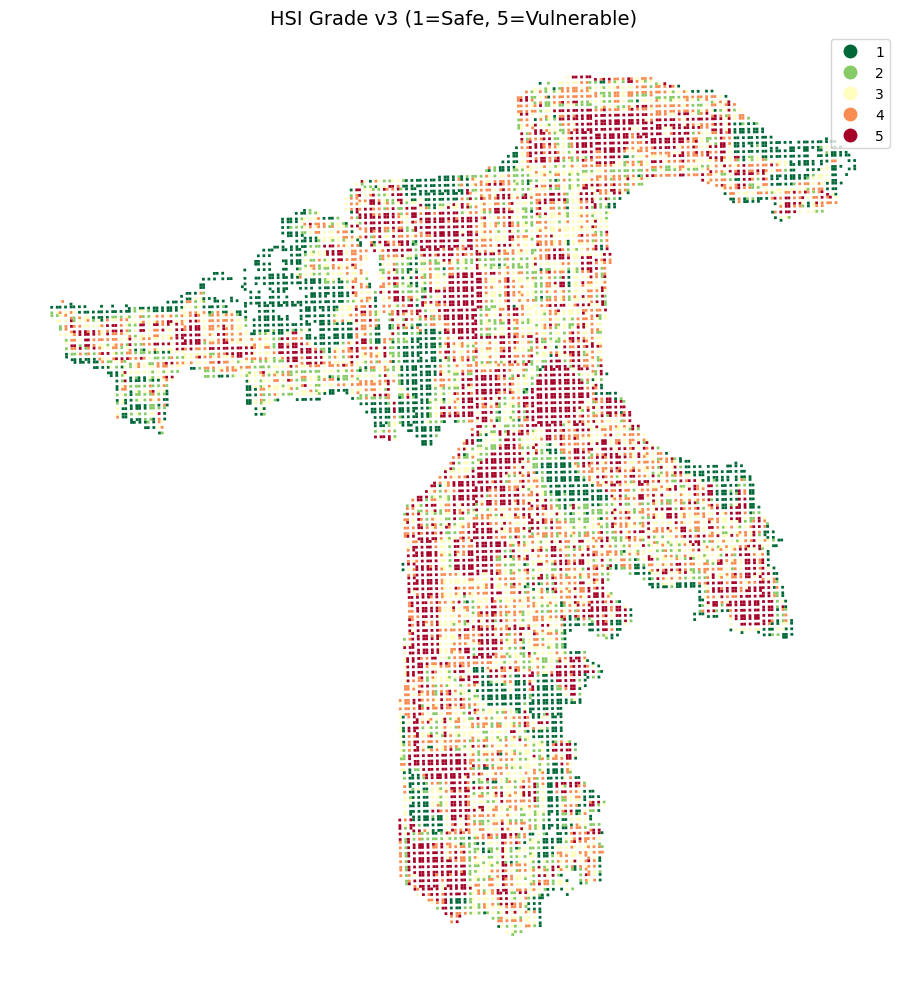

In [72]:
## 셀 32: v3 HSI 최종본 지도 시각화

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

df_hsi_v3 = pd.read_csv('grid_HSI_final_result_v3.csv')

if df_hsi_v3['geometry'].dtype == object:
    from shapely import wkt
    df_hsi_v3['geometry'] = df_hsi_v3['geometry'].apply(
        lambda x: wkt.loads(x) if isinstance(x, str) else x
    )

gdf_hsi_v3 = gpd.GeoDataFrame(df_hsi_v3, geometry='geometry', crs='EPSG:4326')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf_hsi_v3.plot(
    column='HSI_grade',
    categorical=True,
    cmap='RdYlGn_r',
    legend=True,
    ax=ax,
    edgecolor='none'
)
ax.set_title('HSI Grade v3 (1=Safe, 5=Vulnerable)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()